# 最急降下法

## データ準備

In [29]:
import pandas as pd
df = pd.read_csv('../data/sample_data.csv')

In [30]:
df

,space,rent
0,20,13.958824
1,25,11.533805
2,28,14.269547
3,30,18.722680
4,36,19.602674
5,51,16.068166
6,55,23.183599
7,62,22.212595
8,83,29.357010
9,103,37.565129


## データの可視化

<Axes: xlabel='space', ylabel='rent'>

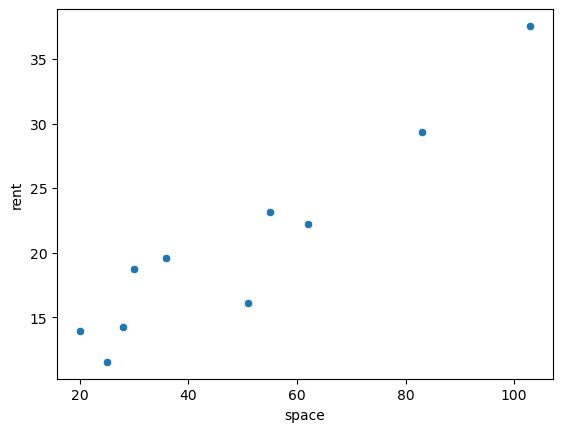

In [31]:
import seaborn as sns
sns.scatterplot(data=df, x='space', y='rent')

## 損失関数定義

In [32]:
import numpy as np

x = df['space'].values
y = df['rent'].values

theta_0 = 2
theta_1 = 1
np.mean(np.square(y - (theta_0 + theta_1 * x)))

def cost_func(theta_0, theta_1, x, y):
    return np.mean(np.square(y - (theta_0 + theta_1 * x)))

cost_func(5, 7, x=x, y=y)

np.float64(138703.20244638805)

## 損失関数の可視化

### ヒント

In [5]:
x = np.array([1, 2, 3, 4])
y = np.array([10, 20, 30, 40])
X, Y = np.meshgrid(x, y)

In [8]:
from itertools import product
z = [x*y for x, y in product(y, x)]
Z = np.array(z).reshape(4, 4)
Z

array([[ 10,  20,  30,  40],
       [ 20,  40,  60,  80],
       [ 30,  60,  90, 120],
       [ 40,  80, 120, 160]])

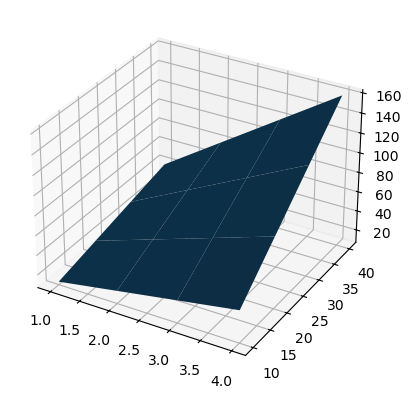

In [9]:
import matplotlib.pyplot as plt
ax = plt.axes(projection='3d')
ax.plot_surface(X=X.T, Y=Y.T, Z=Z)

In [37]:
import matplotlib.pyplot as plt
from itertools import product

n0 = n1 =300
min_0 = -20
max_0 = 20
min_1 = -1
max_1 = 1

theta_0 = np.linspace(min_0, max_0, n0)
theta_1 = np.linspace(min_1, max_1, n1)
theta_0_ax, theta_1_ax = np.meshgrid(theta_0, theta_1)
product(theta_0, theta_1)
z = [cost_func(param[0], param[1], x=x, y=y) for param in list(product(theta_0, theta_1))]
Z = np.array(z).reshape(n0, n1)

In [24]:
Z.shape

(300, 300)

In [19]:
theta_0[0]

np.float64(-20.0)

In [20]:
theta_1[0]

np.float64(-1.0)

In [21]:
cost_func(theta_0[0], theta_1[0], x=x, y=y)

np.float64(2407.5)

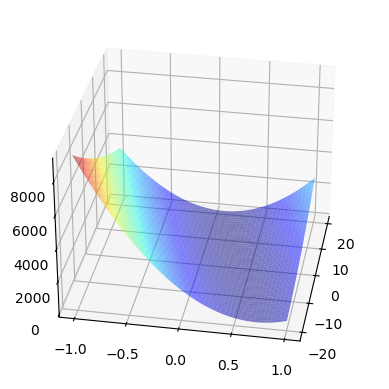

In [41]:
ax = plt.axes(projection='3d')
ax.plot_surface(theta_0_ax.T, theta_1_ax.T, Z, cmap='jet', alpha=0.5)
plt.gca().invert_xaxis()
ax.view_init(elev=30, azim=10)

In [28]:
print(type(plt))

<class 'module'>


## 最急降下法

In [53]:
#np.random.seed(0)
#theta_0_init = np.random.uniform(min_0, max_0)
#theta_1_init = np.random.uniform(min_1, max_1)

theta_0_init = -5
theta_1_init = -0.5

def update_theta0(theta_0, theta_1, x, y, alpha=0.05):
    return theta_0 - alpha * 2 * np.mean((theta_0 + theta_1 * x) - y)

def update_theta1(theta_0, theta_1, x, y, alpha=0.05):
    return theta_1 - alpha * 2 * np.mean(((theta_0 + theta_1 * x) - y) * x)

epochs = 100000
alpha = 0.00005

theta_0_hist = []
theta_1_hist = []
theta_0_hist.append(theta_0_init)
theta_1_hist.append(theta_1_init)

for _ in range(epochs):
    updated_theta_0 = update_theta0(theta_0_hist[-1], theta_1_hist[-1], x=x, y=y, alpha=alpha)
    updated_theta_1 = update_theta1(theta_0_hist[-1], theta_1_hist[-1], x=x, y=y, alpha=alpha)
    theta_0_hist.append(updated_theta_0)
    theta_1_hist.append(updated_theta_1)

In [50]:
update_theta0(theta_0_init, theta_1_init, x=x, y=y, alpha=0.00005)

np.float64(-4.994970259715448)

In [51]:
update_theta1(theta_0_init, theta_1_init, x=x, y=y, alpha=0.00005)

np.float64(-0.2003645901822223)

In [56]:
print(theta_0_hist[-1])
print(theta_1_hist[-1])

5.692313583745944
0.2972194648547114


## 結果の描画

In [57]:
a = [1, 2, 3]
b = [10, 20, 30]

In [58]:
list(zip(a, b))

[(1, 10), (2, 20), (3, 30)]

In [61]:
cost_hist = [cost_func (*param, x=x, y=y) for param in zip(theta_0_hist, theta_1_hist)]

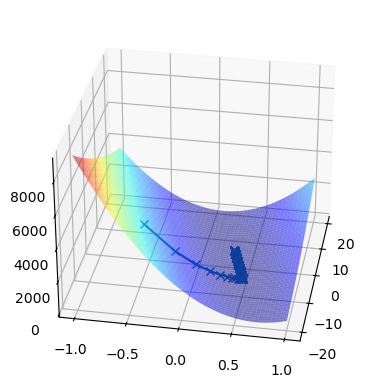

In [66]:
ax = plt.axes(projection='3d')
ax.plot(theta_0_hist, theta_1_hist, cost_hist, 'x-')
ax.plot_surface(theta_0_ax.T, theta_1_ax.T, Z, cmap='jet', alpha=0.5)
plt.gca().invert_xaxis()
ax.view_init(elev=30, azim=10)

Text(0, 0.5, 'theta 0')

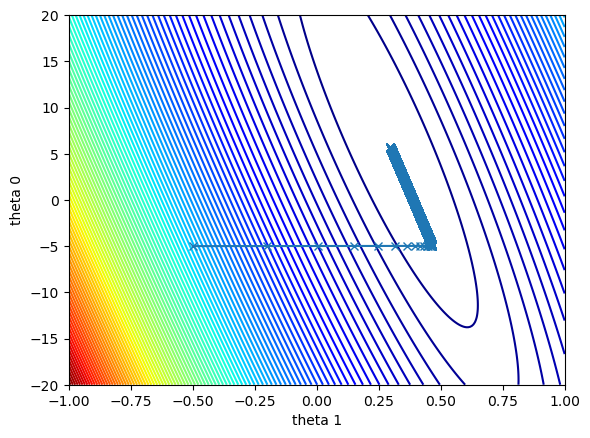

In [68]:
plt.contour(theta_1_ax.T, theta_0_ax.T, Z, 100, cmap='jet')
plt.plot(theta_1_hist, theta_0_hist, 'x-')
plt.xlabel('theta 1')
plt.ylabel('theta 0')

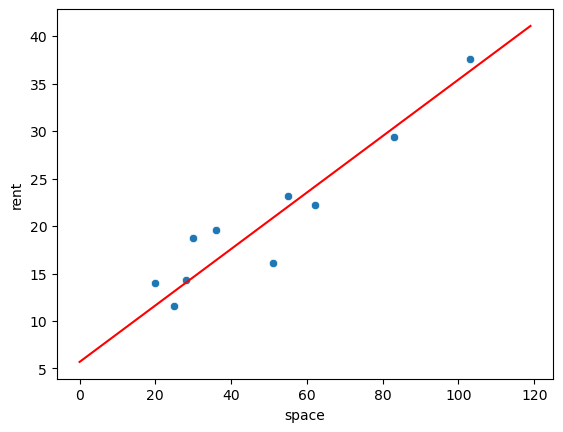

In [75]:
import seaborn as sns
sns.scatterplot(data=df, x='space', y='rent')
x_values = np.arange(120)
y_values = theta_0_hist[-1] + theta_1_hist[-1]*x_values
plt.plot(x_values, y_values, '-', color='r')

In [73]:
x_values

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119])

In [74]:
y_values

array([ 5.69231358,  5.98953305,  6.28675251,  6.58397198,  6.88119144,
        7.17841091,  7.47563037,  7.77284984,  8.0700693 ,  8.36728877,
        8.66450823,  8.9617277 ,  9.25894716,  9.55616663,  9.85338609,
       10.15060556, 10.44782502, 10.74504449, 11.04226395, 11.33948342,
       11.63670288, 11.93392235, 12.23114181, 12.52836128, 12.82558074,
       13.12280021, 13.42001967, 13.71723913, 14.0144586 , 14.31167806,
       14.60889753, 14.90611699, 15.20333646, 15.50055592, 15.79777539,
       16.09499485, 16.39221432, 16.68943378, 16.98665325, 17.28387271,
       17.58109218, 17.87831164, 18.17553111, 18.47275057, 18.76997004,
       19.0671895 , 19.36440897, 19.66162843, 19.9588479 , 20.25606736,
       20.55328683, 20.85050629, 21.14772576, 21.44494522, 21.74216469,
       22.03938415, 22.33660362, 22.63382308, 22.93104255, 23.22826201,
       23.52548148, 23.82270094, 24.1199204 , 24.41713987, 24.71435933,
       25.0115788 , 25.30879826, 25.60601773, 25.90323719, 26.20

In [76]:
space = 70
rent = theta_0_hist[-1] + theta_1_hist[-1]*space

In [77]:
rent

np.float64(26.497676123575744)

# 正規方程式

In [81]:
import numpy as np
import pandas as pd

df = pd.read_csv('../data/sample_data.csv')

x = df['space'].values
y = df['rent'].values

In [90]:
X = np.vstack([np.ones(len(x)), x]).T

In [93]:
best_theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y.T)

In [94]:
best_theta

array([7.0962325 , 0.27487161])

In [95]:
print(theta_0_hist[-1])
print(theta_1_hist[-1])

5.692313583745944
0.2972194648547114


Text(0, 0.5, 'theta 0')

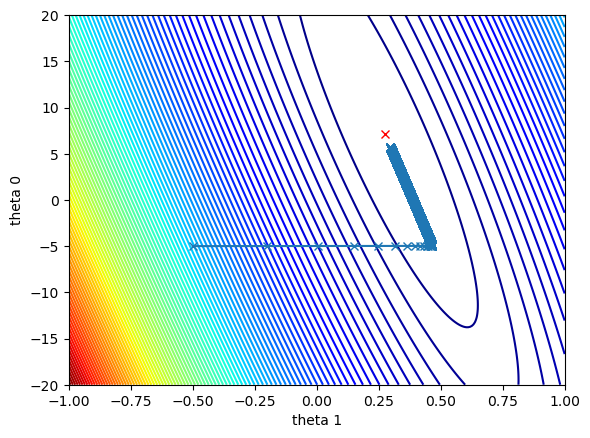

In [96]:
plt.contour(theta_1_ax.T, theta_0_ax.T, Z, 100, cmap='jet')
plt.plot(theta_1_hist, theta_0_hist, 'x-')
plt.plot(best_theta[1], best_theta[0], 'x', color='red')
plt.xlabel('theta 1')
plt.ylabel('theta 0')

### scikit-learnで線形回帰

In [97]:
from sklearn.linear_model import LinearRegression

In [114]:
model = LinearRegression()
# データの準備
x = df['space'].values
y = df['rent']
X = x.reshape(-1, 1)
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [115]:
model.predict(X)

array([12.59366469, 13.96802274, 14.79263756, 15.34238078, 16.99161044,
       21.11468458, 22.21417102, 24.13827229, 29.91057608, 35.40800827])

In [116]:
X

array([[ 20],
       [ 25],
       [ 28],
       [ 30],
       [ 36],
       [ 51],
       [ 55],
       [ 62],
       [ 83],
       [103]])

In [117]:
model.coef_

array([0.27487161])

In [118]:
model.intercept_

np.float64(7.0962324999088295)